In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import data and assign the same colours as used in the renders for ease of understanding
ec_snr_data = pd.read_csv("Data/ec_snr_data_with_clusters.csv")

label_map = {
    0: "long_xlong_STRd_STRv_AI^ORB~very_lateral",
    1: "med_short_RSP_VIS^RSP~very_medial",
    2: "med_xlong_RSP_VIS_STR^blend~medial",
    3: "short_HIP_SUB^RSP~very_medial",
    4: "med_RSP_VIS_TEa^blend~medial",
    5: "med_AMY_STRv_STRd^ORB~very_lateral",
    6: "xshort_mixed^none~medial"
}

cluster_label_order = [3, 1, 2, 5, 0, 4, 6]
cluster_order = [label_map[i] for i in cluster_label_order]

cluster_colours = {
    cluster_order[0]: "brown",
    cluster_order[1]: "orange",
    cluster_order[2]: "red",
    cluster_order[3]: "green",
    cluster_order[4]: "blue",
    cluster_order[5]: "pink",
    cluster_order[6]: "cyan",
}

# Boxplot of spread of x,y,z values in CCF framework

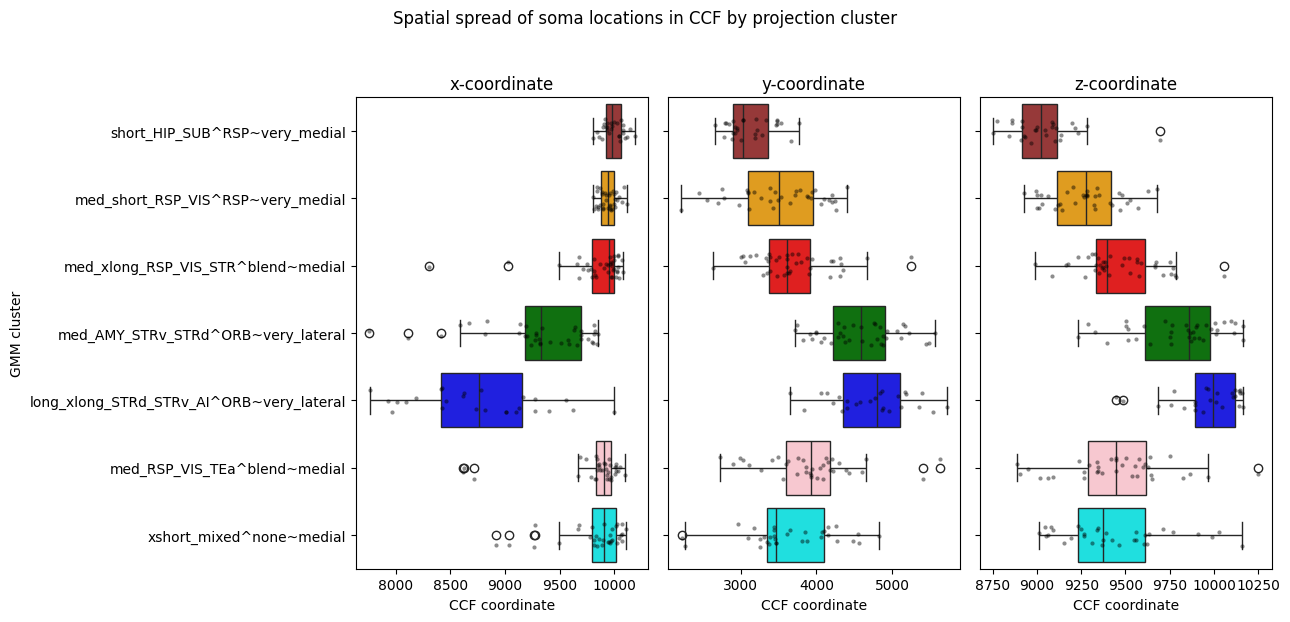

In [3]:
df_plot = ec_snr_data.copy()

cluster_col = "label_names"
coord_cols = ["x", "y", "z"]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(13, 6),
    sharey=True
)

for ax, coord in zip(axes, coord_cols):
    sns.boxplot(
        data=df_plot,
        y=cluster_col,
        x=coord,
        order=cluster_order,
        hue=cluster_col,
        hue_order=cluster_order,
        palette=cluster_colours,
        orient="h",
        dodge=False,
        ax=ax,
        showfliers=True
    )

    sns.stripplot(
        data=df_plot,
        y=cluster_col,
        x=coord,
        order=cluster_order,
        orient="h",
        ax=ax,
        color="black",
        alpha=0.45,
        size=3,
        jitter=0.18
    )

    ax.set_title(f"{coord}-coordinate")
    ax.set_xlabel("CCF coordinate")
    ax.set_ylabel("GMM cluster" if coord == "x" else "")

plt.suptitle("Spatial spread of soma locations in CCF by projection cluster", y=1.03)
plt.tight_layout()
fig.savefig(
    "Figures/fig_9_snr_location_boxplot.png",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()